In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
folder="/content/drive/MyDrive/資料科學自學聖經/ch10"

## 10.3.2 蒐集資料：MNIST 資料集

讀取 MNIST 資料集

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
#訓練集:(train_feature, train_label)   測試集:(test_feature, test_label)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

(train_feature, train_label), (test_feature, test_label) = \
    mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


查看MNIST資料型態

1.使用len()查看資料長度

In [4]:
print(len(train_feature),len(train_label))
print(len(test_feature),len(test_label))

60000 60000
10000 10000


2.使用shape()查看其維度

In [5]:
print(train_feature.shape,train_label.shape)

(60000, 28, 28) (60000,)


3.查看訓練圖片與標籤值

數字圖形如下，標籤為：5


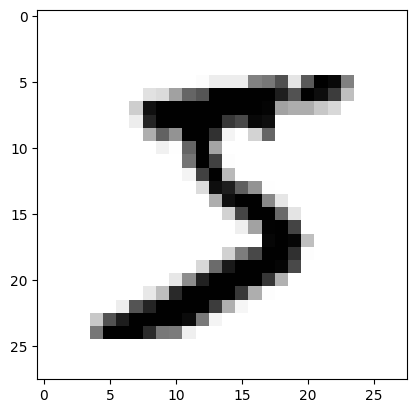

In [9]:
import matplotlib.pyplot as plt

print('數字圖形如下，標籤為：{}'.format(train_label[0]))
plt.imshow(train_feature[0], cmap='binary')

載入互動模組 ipywidgets 建立滑桿快速查看圖片

interactive(children=(IntSlider(value=29999, description='n', max=59999), Output()), _dom_classes=('widget-int…

<function __main__.show_number(n)>

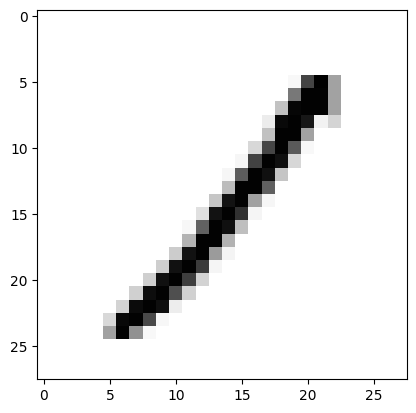

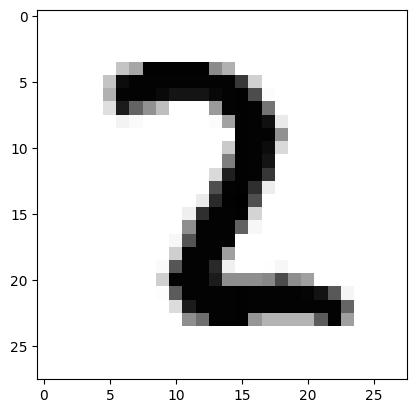

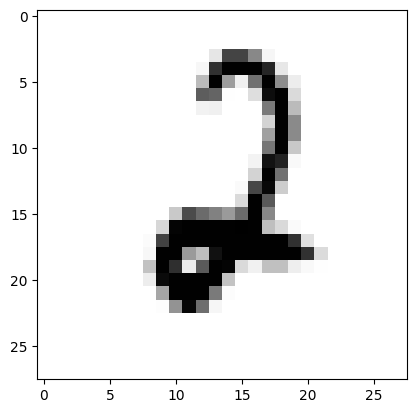

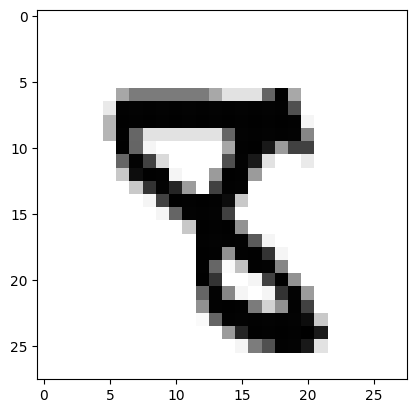

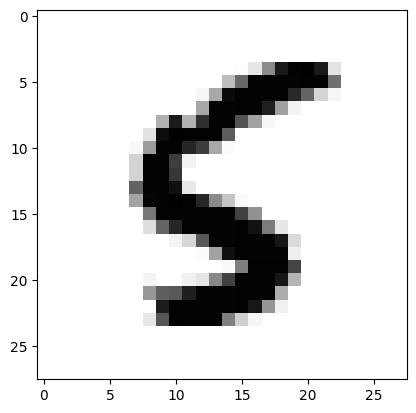

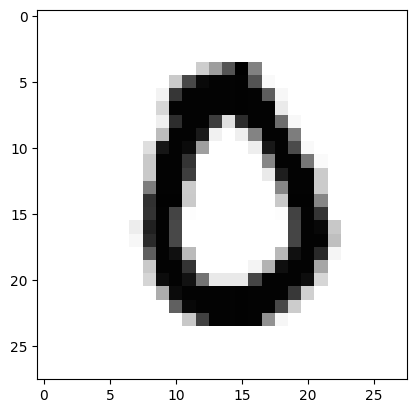

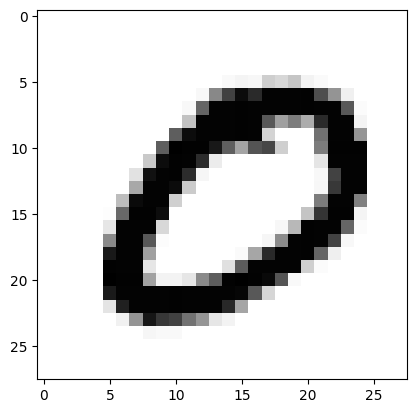

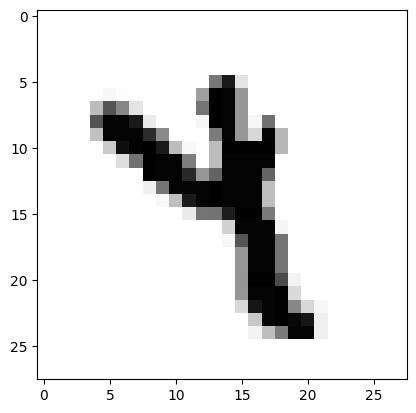

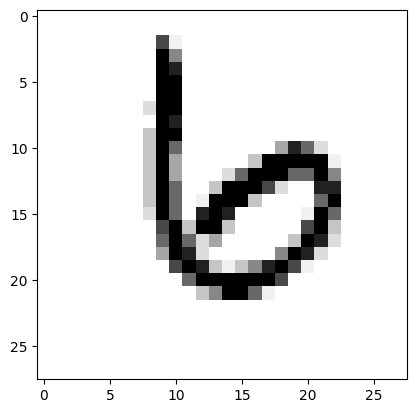

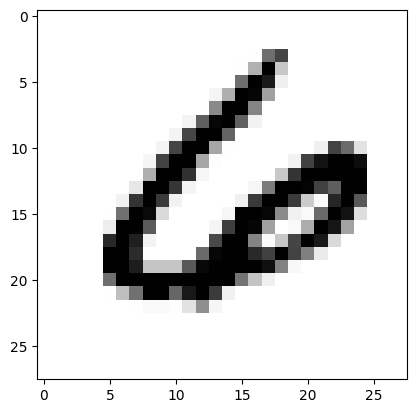

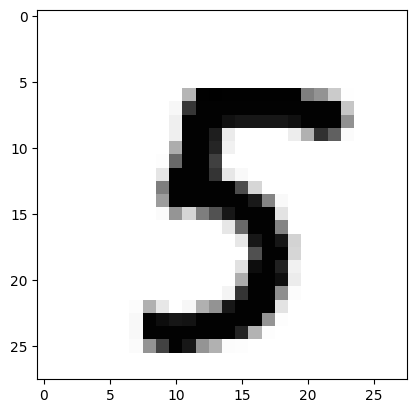

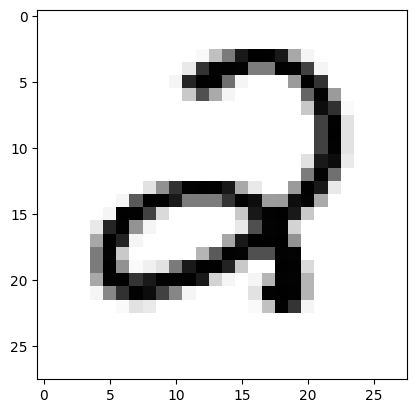

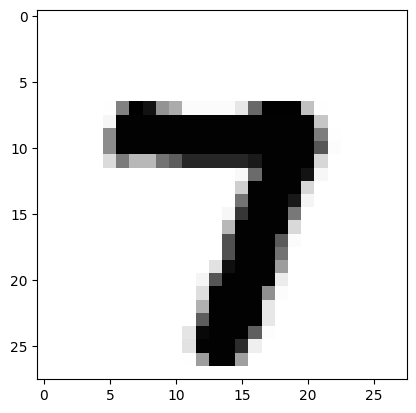

In [10]:
from ipywidgets import interact

def show_number(n):
  print('數字圖形如下，標籤為：{}'.format(train_label[n]))
  plt.imshow(train_feature[n], cmap='Greys')

interact(show_number, n=(0, 59999))

## 10.3.3 資料預處理

將28*28的二維向量圖片,轉換為784個數值的一維向量

In [11]:
train_feature =train_feature.reshape(len(train_feature),784)
test_feature = test_feature.reshape(len(test_feature),784)
print(train_feature.shape,test_feature.shape)

(60000, 784) (10000, 784)


顯示第一張圖片資料內容

In [12]:
print(train_feature[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 247 241   0   0   0   0   

資料標準化:

由於向量圖型的資料範圍是0-255,除以255將資料轉換為0-1之間的數值,以提高精準度

In [13]:
train_feature = train_feature/255
test_feature = test_feature/255
print(train_feature[0])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

標籤資料預處理:

將標籤值0-9,利用One-Hot編碼機制,轉換為0與1

In [14]:
print(train_label[0:5])

[5 0 4 1 9]


載入Keras中的np_utils模組,使用to_categorical方法轉換One-Hot編碼(舊版寫法)

In [15]:
import tensorflow as tf
from tensorflow import keras
from keras.utils import np_utils
train_label = np_utils.to_categorical(train_label)
test_label = np_utils.to_categorical(test_label)
print(train_label[0:5])

ImportError: cannot import name 'np_utils' from 'keras.utils' (/usr/local/lib/python3.10/dist-packages/keras/utils/__init__.py)

[更新版語法] 更新keras與tensorflow套件  

In [16]:
!pip install --upgrade keras
!pip install --upgrade tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.7/347.7 kB 13.2 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.4.1 which is incompatible.


     ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/601.3 MB 67.5 MB/s eta 0:00:08ERROR: Operation cancelled by user
     ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/601.3 MB 57.6 MB/s eta 0:00:09


[更新版語法]如何辨識手寫阿拉伯數字短程式測試  
※參考網址: https://ithelp.ithome.com.tw/articles/10233758

In [1]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist

# 匯入 MNIST 手寫阿拉伯數字 訓練資料
(x_train, y_train),(x_test, y_test) = mnist.load_data()
# 特徵縮放，使用常態化(Normalization)，公式 = (x - min) / (max - min)
# 顏色範圍：0~255，所以，公式簡化為 x / 255
x_train, x_test = x_train / 255.0, x_test / 255.0

# 建立模型
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

# 設定優化器(optimizer)、損失函數(loss)、效能衡量指標(metrics)的類別
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 模型訓練
model.fit(x_train, y_train, epochs=5)
# 模型評估，打分數
model.evaluate(x_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8610 - loss: 0.4856
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9557 - loss: 0.1520
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9685 - loss: 0.1016
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9734 - loss: 0.0867
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9766 - loss: 0.0745
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9709 - loss: 0.0906


[0.07811826467514038, 0.9751999974250793]

[更新版語法]顯示圖片資料

In [2]:
# 將非0的數字轉為1，顯示第1張圖片
data = x_train[0].copy()
data[data>0]=1

# 將轉換後二維內容顯示出來，隱約可以看出數字為 5
text_image=[]
for i in range(data.shape[0]):
    text_image.append(''.join(str(data[i])))
text_image

['[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0.]',
 '[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 

[更新版語法]訓練資料80%，測試資料占20%

In [3]:
# 訓練
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9810 - loss: 0.0616 - val_accuracy: 0.9878 - val_loss: 0.0378
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9831 - loss: 0.0529 - val_accuracy: 0.9858 - val_loss: 0.0488
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9841 - loss: 0.0501 - val_accuracy: 0.9837 - val_loss: 0.0513
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9849 - loss: 0.0477 - val_accuracy: 0.9855 - val_loss: 0.0465
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9865 - loss: 0.0393 - val_accuracy: 0.9852 - val_loss: 0.0487


[更新版語法]對訓練過程的準確度/損失函數繪圖

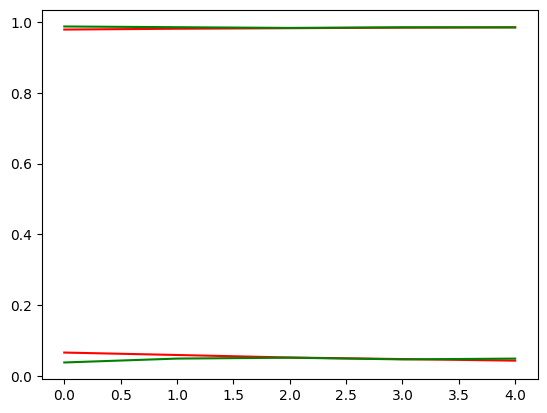

In [4]:
# 對訓練過程的準確度繪圖
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], 'r')
plt.plot(history.history['val_accuracy'], 'g')

# 對訓練過程的損失函數繪圖
plt.plot(history.history['loss'], 'r')
plt.plot(history.history['val_loss'], 'g')

[更新版語法]實際預測 N 筆，觀察結果，發現第9筆錯誤，顯示錯誤的圖片

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
prediction: [[1.70575010e-09 1.15552241e-10 1.34731302e-08 1.52868506e-05
  1.48357075e-13 4.04013739e-10 3.92995759e-16 9.99984384e-01
  1.61508673e-08 3.12246897e-07]
 [1.83169972e-12 5.04528180e-05 9.99949574e-01 1.06472475e-08
  3.03538029e-20 3.10479385e-11 5.58875591e-13 9.33913794e-15
  6.25870666e-12 6.93061393e-19]
 [1.97204187e-07 9.99829054e-01 3.32785612e-06 9.14183005e-08
  1.15325588e-06 7.12662313e-07 2.06583422e-06 1.47242405e-04
  1.60328327e-05 5.60889788e-08]
 [9.99992371e-01 6.76620149e-11 5.10104485e-07 7.33727390e-08
  1.39216927e-09 4.62627668e-06 7.56654231e-07 9.74780164e-07
  3.17685628e-10 6.78490210e-07]
 [1.22085567e-07 8.07581016e-11 1.17043079e-07 3.73643427e-09
  9.99940991e-01 3.07348202e-10 8.63403127e-09 1.66450388e-06
  9.82678472e-09 5.70989323e-05]
 [2.31309745e-08 9.99512792e-01 1.84445401e-08 3.66247903e-08
  3.94917919e-07 2.39944331e-09 8.61275495e-09 4.85996949e-04
  6.71366195e-07 8.18028667e-08]
 [7.1

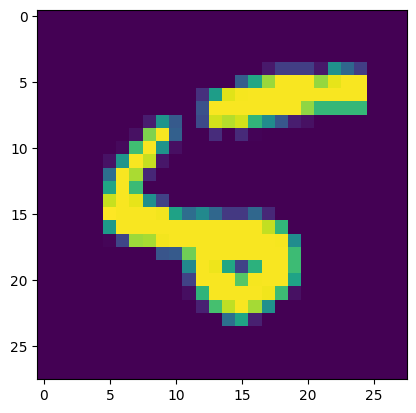

In [5]:
# 實際預測 20 筆
#predictions = model.predict_classes(x_test)
predictions=model.predict(x_test)
#classes_x=np.argmax(predict_x,axis=1)

# get prediction result
print('prediction:', predictions[0:20])
print('actual    :', y_test[0:20])

# 顯示錯誤的資料圖像
X2 = x_test[8,:,:]
plt.imshow(X2.reshape(28,28))
plt.show()

[更新版程式]顯示模型的彙總資訊、模型存檔/載入、模型繪圖

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,772 (397.55 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

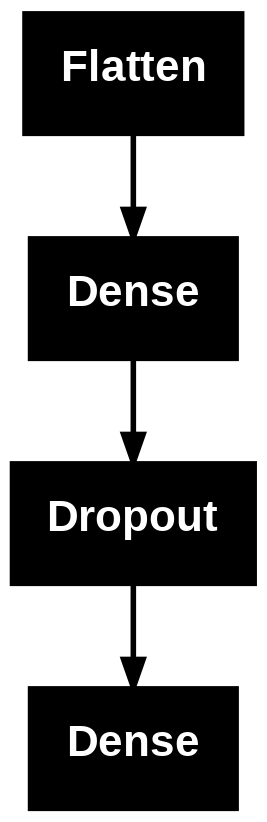

In [7]:
# 顯示模型的彙總資訊
model.summary()

# 模型存檔 ※Keras使用HDF5檔案系統(*.h5)來儲存模型
model.save('model.h5')#預設儲存在\content目錄

# 模型載入
model = tf.keras.models.load_model('model.h5')

# 繪製模型
# 需安裝 graphviz (https://www.graphviz.org/download/)
# 將安裝路徑 C:\Program Files (x86)\Graphviz2.38\bin 新增至環境變數 path 中
# pip install graphviz
# pip install pydotplus
tf.keras.utils.plot_model(model, to_file='model.png')

[更新版程式]載入模型

In [8]:
from keras.models import load_model
model = load_model('model.h5')
score = model.evaluate(x_test, y_test, verbose=2)
print('\n準確率=',score[1])


313/313 - 1s - 3ms/step - accuracy: 0.9791 - loss: 0.0699

準確率= 0.9790999889373779


## 10.3.4 建立全連結神經網路模型

1.建立Sequential模型

In [ ]:
from keras.models import Sequential

TypeError: ignored

2.建立 Sequential物件

In [ ]:
models = Sequential()

ModuleNotFoundError: ignored

In [ ]:
#model = tf.keras.models.Sequential([
#    tf.keras.layers.Flatten(input_shape=(50,50)),
#    tf.keras.layers.Dense(128, activation='relu'),
#    tf.keras.layers.Dense(10, activation='softmax')
#])

建立全連結層

1.建立輸入層與第1層隱藏層:輸入資料有784個資料元,隱藏層有50個神經元,激勵函式為ReLu

In [ ]:
model.add(Dense(units=50, input_dim=784, activation='relu'))

2.建立兩層隱藏層:第2層隱藏層有100個神經元,第3隱藏層有200個神經元,兩層激勵函式皆為ReLu

In [ ]:
model.add(Dense(units=100, activation='relu'))
model.add(Dense(units=200, activation='relu'))

3.建立輸出層:輸出資料有10個,激勵函式為:SoftMax

In [ ]:
model.add(Dense(units=10, activation='softmax'))

查看權重數量

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 50)                39250     
                                                                 
 dense_8 (Dense)             (None, 100)               5100      
                                                                 
 dense_9 (Dense)             (None, 200)               20200     
                                                                 
 dense_10 (Dense)            (None, 10)                2010      
                                                                 
Total params: 66,560
Trainable params: 66,560
Non-trainable params: 0
_________________________________________________________________


## 10.3.5 訓練模型

1.設定模型的訓練方式

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

2.利用fit()方法進行訓練

In [ ]:
model.fit(x=train_feature, y=train_label, validation_split=0.2, epochs=10, batch_size=200, verbose=2)

Epoch 1/10
240/240 - 5s - loss: 0.4767 - accuracy: 0.8597 - val_loss: 0.2222 - val_accuracy: 0.9314 - 5s/epoch - 19ms/step
Epoch 2/10
240/240 - 2s - loss: 0.1848 - accuracy: 0.9456 - val_loss: 0.1571 - val_accuracy: 0.9551 - 2s/epoch - 7ms/step
Epoch 3/10
240/240 - 1s - loss: 0.1366 - accuracy: 0.9603 - val_loss: 0.1461 - val_accuracy: 0.9567 - 1s/epoch - 6ms/step
Epoch 4/10
240/240 - 2s - loss: 0.1127 - accuracy: 0.9667 - val_loss: 0.1260 - val_accuracy: 0.9632 - 2s/epoch - 7ms/step
Epoch 5/10
240/240 - 2s - loss: 0.0932 - accuracy: 0.9720 - val_loss: 0.1184 - val_accuracy: 0.9653 - 2s/epoch - 7ms/step
Epoch 6/10
240/240 - 2s - loss: 0.0779 - accuracy: 0.9762 - val_loss: 0.1131 - val_accuracy: 0.9668 - 2s/epoch - 7ms/step
Epoch 7/10
240/240 - 2s - loss: 0.0697 - accuracy: 0.9786 - val_loss: 0.1112 - val_accuracy: 0.9682 - 2s/epoch - 7ms/step
Epoch 8/10
240/240 - 2s - loss: 0.0596 - accuracy: 0.9819 - val_loss: 0.1158 - val_accuracy: 0.9654 - 2s/epoch - 10ms/step
Epoch 9/10
240/240 - 2

## 10.3.6 評估準確率及存取模型

1.設定評估變數為score,使用10000筆測試資料評估模型的準確率

In [ ]:
score = model.evaluate(x=test_feature, y=test_label, verbose=2)
print('\n準確率=',score[1])

313/313 - 1s - loss: 0.1091 - accuracy: 0.9689 - 623ms/epoch - 2ms/step

準確率= 0.9689000248908997


2.儲存模型( *.h5)

※Keras使用HDF5檔案系統來儲存模型

In [ ]:
model.save('mnist_model.h5')

3.載入模型

In [ ]:
from keras.models import load_model
model2 = load_model('mnist_model.h5')
score = model2.evaluate(x=test_feature, y=test_label, verbose=2)
print('\n準確率=',score[1])

313/313 - 1s - loss: 0.1091 - accuracy: 0.9689 - 616ms/epoch - 2ms/step

準確率= 0.9689000248908997


## 10.3.7完整手寫數字模型程式碼

In [9]:
from keras.datasets import mnist
from keras.utils import np_utils
from keras.models import Sequential
from keras.layers import Dense

(train_feature, train_label), (test_feature, test_label) = mnist.load_data()
train_feature =train_feature.reshape(len(train_feature),784)
test_feature = test_feature.reshape(len(test_feature),784)
train_feature = train_feature/255
test_feature = test_feature/255
train_label = np_utils.to_categorical(train_label)
test_label = np_utils.to_categorical(test_label)

model = Sequential()
model.add(Dense(units=50, input_dim=784, activation='relu'))
model.add(Dense(units=100, activation='relu'))
model.add(Dense(units=200, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.compile(loss='categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])
model.fit(x=train_feature, y=train_label,
          validation_split=0.2, epochs=10,
          batch_size=200, verbose=2)
score = model.evaluate(x=test_feature, y=test_label, verbose=2)
print('\n測試資料準確率:',score[1])
model.save('mnist_model.h5')

ImportError: cannot import name 'np_utils' from 'keras.utils' (/usr/local/lib/python3.10/dist-packages/keras/api/utils/__init__.py)

## 10.3.8 預測自己的數字圖片

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
import glob, cv2

def show_images_labels_predictions(images, labels,
                                   predictions, start_id, num=10):
    plt.figure(figsize=(12, 14))
    if num>25: num=25
    for i in range(0, num):
        ax=plt.subplot(5,5, 1+i)
        ax.imshow(images[start_id], cmap='binary')
        if( len(predictions) > 0 ) :
            title = 'ai = ' + str(predictions[start_id])
            title += (' (o)' if predictions[start_id]== \
                      labels[start_id] else ' (x)')
            title += '\nlabel = ' + str(labels[start_id])
        else :
            title = 'label = ' + str(labels[start_id])
        ax.set_title(title,fontsize=12)
        ax.set_xticks([]);ax.set_yticks([])
        start_id+=1
    plt.show()

files = glob.glob("/content/drive/MyDrive/資料科學自學聖經/ch10/*.jpg" )
test_feature=[]
test_label=[]
for file in files:
    img=cv2.imread(file)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    test_feature.append(img)
    # label=file[9:10]
    label = file.split("/")[-1][0]
    # test_label.append(int(label))
    test_label.append(int(label))

test_feature=np.array(test_feature)
test_label=np.array(test_label)
test_feature_v = test_feature.reshape(len(test_feature), 784)
test_feature_n = test_feature_v/255
model = load_model('model.h5')
prediction=model.predict(test_feature_n)
#prediction=tf.config.run_functions_eagerly(True)
prediction=np.argmax(prediction,axis=1)

show_images_labels_predictions(test_feature, test_label,
                               prediction, 0, len(test_feature))

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(10, 784), dtype=float32). Expected shape (None, 28, 28), but input has incompatible shape (10, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(10, 784), dtype=float32)
  • training=False
  • mask=None

## 10.4 gradio模組：深度學習成果展示

In [11]:
!pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 34.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.8/857.8 kB 44.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.1/318.1 kB 34.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.1/141.1 kB 18.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 67.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 20.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 9.8 

10.4.1 Gradio 模組基本操作

In [12]:
!pip install --upgrade gradio
import gradio as gr

def replace1(text):
  return text.replace('morning', 'evening')

grobj = gr.Interface(fn=replace1,
                     inputs=gr.inputs.Textbox(),
                     outputs=gr.outputs.Textbox())
grobj.launch()

AttributeError: module 'gradio' has no attribute 'inputs'

10.4.2 Gradio 模組輸入欄位

文字輸入欄位:Textbox

In [14]:
import gradio as gr
def replace1(text):
  return text.replace('morning', 'evening')

grobj = gr.Interface(fn=replace1,
                     inputs = gr.inputs.Textbox(lines=5,                                            default='good morning',
                                              label='輸入文句'),
                     outputs = gr.outputs.Textbox())
grobj.launch()

AttributeError: module 'gradio' has no attribute 'inputs'

圖片輸入欄位:Textbox

In [ ]:
from tensorflow.keras.models import load_model
import gradio as gr

#model = load_model("/content/drive/MyDrive/資料科學自學聖經/ch10/testMnist.h5")
model = load_model("/content/mnist_model.h5")

def mnist(image):
    #image = image.reshape(1, -1)
    image = image.reshape(1,784)#修改 reshape
    prediction = model.predict(image).tolist()[0]
    return {str(i): prediction[i] for i in range(10)}

out = gr.outputs.Label(num_top_classes=3,
                       label='預測結果')
grobj = gr.Interface(fn=mnist,
                     inputs="sketchpad",
                     outputs=out, title="手寫數字")
grobj.launch(share=True)

/usr/local/lib/python3.10/dist-packages/gradio/outputs.py:197: UserWarning: Usage of gradio.outputs is deprecated, and will not be supported in the future, please import your components from gradio.components
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gradio/deprecation.py:40: UserWarning: The 'type' parameter has been deprecated. Use the Number component instead.
  warnings.warn(value)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://6cbf3ce00683bdf5a8.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades (NEW!), check out Spaces: https://huggingface.co/spaces


### 10.5 過擬合

實作過擬合現象

In [15]:
from keras.datasets import mnist
from keras.utils import np_utils
from keras.models import Sequential
from keras.layers import Dense

(train_feature, train_label), (test_feature, test_label) = mnist.load_data()
train_feature =train_feature.reshape(len(train_feature),784)
test_feature = test_feature.reshape(len(test_feature),784)
train_feature = train_feature/255
test_feature = test_feature/255
train_label = np_utils.to_categorical(train_label)
test_label = np_utils.to_categorical(test_label)

model = Sequential()
model.add(Dense(units=50, input_dim=784, activation='relu'))
model.add(Dense(units=100, activation='relu'))
model.add(Dense(units=200, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam',
              metrics=['accuracy'])
fitmodel = model.fit(x=train_feature, y=train_label, validation_split=0.2,
                     epochs=40,
                     batch_size=200, verbose=2)

ImportError: cannot import name 'np_utils' from 'keras.utils' (/usr/local/lib/python3.10/dist-packages/keras/api/utils/__init__.py)

In [ ]:
print('訓練資料正確率：\n{}'.format(fitmodel.history['accuracy']))
print('驗證資料正確率：\n{}'.format(fitmodel.history['val_accuracy']))

訓練資料正確率：
[0.8604791760444641, 0.9475833177566528, 0.9605208039283752, 0.9693333506584167, 0.9730416536331177, 0.9767500162124634, 0.9808333516120911, 0.9829999804496765, 0.9848750233650208, 0.9864374995231628, 0.9885416626930237, 0.9896249771118164, 0.9903333187103271, 0.9923750162124634, 0.99239581823349, 0.9928749799728394, 0.9942291378974915, 0.9952499866485596, 0.9952083230018616, 0.9956250190734863, 0.9945625066757202, 0.9955833554267883, 0.9958333373069763, 0.9964791536331177, 0.9975208044052124, 0.9941666722297668, 0.996708333492279, 0.9970208406448364, 0.9963750243186951, 0.9948124885559082, 0.9982708096504211, 0.9984583258628845, 0.9988750219345093, 0.9992708563804626, 0.9980208277702332, 0.9940416812896729, 0.9968958497047424, 0.9976875185966492, 0.9972500205039978, 0.996791660785675]
驗證資料正確率：
[0.9430000185966492, 0.9545000195503235, 0.9623333215713501, 0.9633333086967468, 0.9632499814033508, 0.96875, 0.9641666412353516, 0.9698333144187927, 0.9694166779518127, 0.9689166545867

過擬合圖形展示


--2023-05-14 19:21:11--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 108.177.127.113, 108.177.127.101, 108.177.127.100, ...
Connecting to drive.google.com (drive.google.com)|108.177.127.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/rcs1ir9ijf6u00vj3fr9v424iat3qind/1684092000000/02847987870453524430/*/1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_?uuid=1a9755ae-7d4f-46ec-b62f-40e4bf89fe97 [following]
--2023-05-14 19:21:12--  https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/rcs1ir9ijf6u00vj3fr9v424iat3qind/1684092000000/02847987870453524430/*/1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_?uuid=1a9755ae-7d4f-46ec-b62f-40e4bf89fe97
Resolving doc-0k-9o-docs.googleusercontent.com (doc-0k-9o-docs.googleusercontent.com)... 173.194.69.132, 2a00:1450:4013:c04::84
Connecting to do

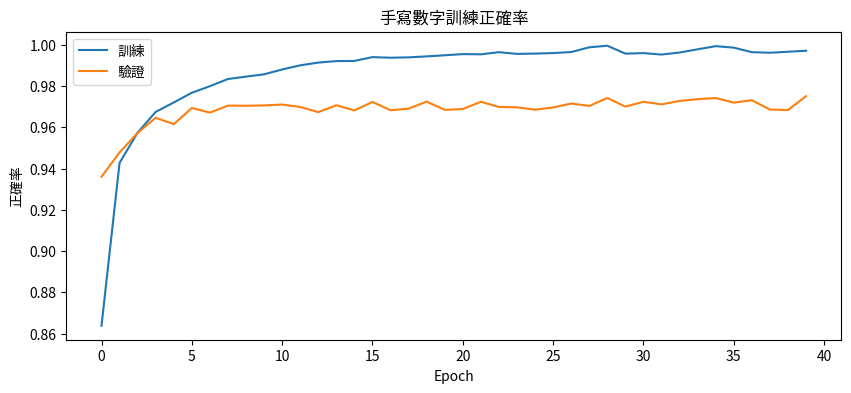

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager

!wget -O TaipeiSansTCBeta-Regular.ttf \
https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
mpl.rc('font', family='Taipei Sans TC Beta')
plt.figure(figsize=(10, 4))
plt.plot(fitmodel.history['accuracy'])
plt.plot(fitmodel.history['val_accuracy'])
plt.title('手寫數字訓練正確率')
plt.xlabel('Epoch')
plt.ylabel('正確率')
plt.legend(['訓練', '驗證'])
plt.show()

10.5.2 加入拋棄層避免過擬合

Epoch 1/40
240/240 - 2s - loss: 0.6673 - accuracy: 0.7896 - val_loss: 0.2286 - val_accuracy: 0.9310 - 2s/epoch - 10ms/step
Epoch 2/40
240/240 - 1s - loss: 0.3030 - accuracy: 0.9079 - val_loss: 0.1691 - val_accuracy: 0.9494 - 780ms/epoch - 3ms/step
Epoch 3/40
240/240 - 1s - loss: 0.2365 - accuracy: 0.9287 - val_loss: 0.1421 - val_accuracy: 0.9570 - 804ms/epoch - 3ms/step
Epoch 4/40
240/240 - 1s - loss: 0.2072 - accuracy: 0.9365 - val_loss: 0.1307 - val_accuracy: 0.9613 - 832ms/epoch - 3ms/step
Epoch 5/40
240/240 - 1s - loss: 0.1853 - accuracy: 0.9429 - val_loss: 0.1218 - val_accuracy: 0.9629 - 807ms/epoch - 3ms/step
Epoch 6/40
240/240 - 1s - loss: 0.1714 - accuracy: 0.9476 - val_loss: 0.1161 - val_accuracy: 0.9663 - 810ms/epoch - 3ms/step
Epoch 7/40
240/240 - 1s - loss: 0.1596 - accuracy: 0.9506 - val_loss: 0.1098 - val_accuracy: 0.9682 - 988ms/epoch - 4ms/step
Epoch 8/40
240/240 - 1s - loss: 0.1501 - accuracy: 0.9537 - val_loss: 0.1047 - val_accuracy: 0.9688 - 1s/epoch - 5ms/step
Epoch

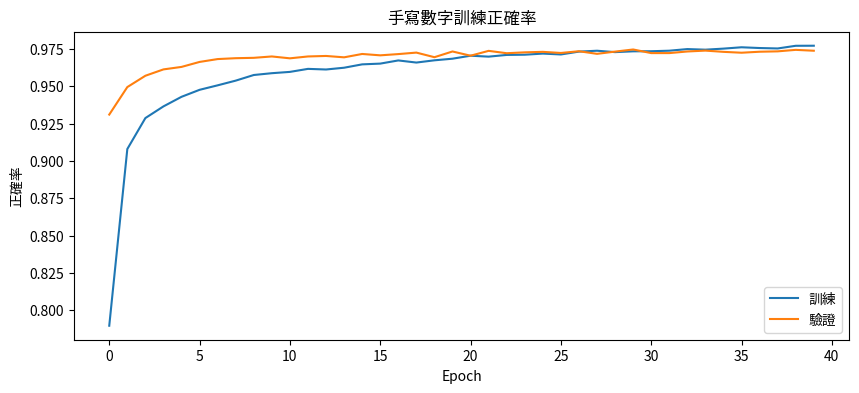

In [ ]:
from keras.datasets import mnist
from keras.utils import np_utils
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager

(train_feature, train_label), (test_feature, test_label) = mnist.load_data()
train_feature =train_feature.reshape(len(train_feature),784)
test_feature = test_feature.reshape(len(test_feature),784)
train_feature = train_feature/255
test_feature = test_feature/255
train_label = np_utils.to_categorical(train_label)
test_label = np_utils.to_categorical(test_label)

model = Sequential()
n = 0.2
model.add(Dense(units=50, input_dim=784, activation='relu'))
model.add(Dropout(n))
model.add(Dense(units=100, activation='relu'))
model.add(Dropout(n))
model.add(Dense(units=200, activation='relu'))
model.add(Dropout(n))
model.add(Dense(units=10, activation='softmax'))
model.compile(loss='categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])
fitmodel = model.fit(x=train_feature, y=train_label,
                     validation_split=0.2, epochs=40,
                     batch_size=200, verbose=2)
!wget -O TaipeiSansTCBeta-Regular.ttf \
https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
mpl.rc('font', family='Taipei Sans TC Beta')
plt.figure(figsize=(10, 4))
plt.plot(fitmodel.history['accuracy'])
plt.plot(fitmodel.history['val_accuracy'])
plt.title('手寫數字訓練正確率')
plt.xlabel('Epoch')
plt.ylabel('正確率')
plt.legend(['訓練', '驗證'])
plt.show()